## PROJECT: Entropy of written English

In [1]:
# import all necessary modules
import numpy as np
import matplotlib.pyplot as plt
import requests
import re
import string

# Import text from website

In [2]:
# get raw text from internet
book = requests.get('https://www.gutenberg.org/files/35/35-0.txt')
book

<Response [200]>

In [3]:
# extract just the text and have a look at it

text = book.text
print(type(text))
print(len(text))

<class 'str'>
179799


In [4]:
# let's see the beginning of it

text[:2000]

'*** START OF THE PROJECT GUTENBERG EBOOK 35 ***\n\n\n\n\nThe Time Machine\n\nAn Invention\n\nby H. G. Wells\n\n\nCONTENTS\n\n I Introduction\n II The Machine\n III The Time Traveller Returns\n IV Time Travelling\n V In the Golden Age\n VI The Sunset of Mankind\n VII A Sudden Shock\n VIII Explanation\n IX The Morlocks\n X When Night Came\n XI The Palace of Green Porcelain\n XII In the Darkness\n XIII The Trap of the White Sphinx\n XIV The Further Vision\n XV The Time Traveller’s Return\n XVI After the Story\n Epilogue\n\n\n\n\n I.\n Introduction\n\n\nThe Time Traveller (for so it will be convenient to speak of him)\nwas expounding a recondite matter to us. His grey eyes shone and\ntwinkled, and his usually pale face was flushed and animated. The\nfire burnt brightly, and the soft radiance of the incandescent\nlights in the lilies of silver caught the bubbles that flashed and\npassed in our glasses. Our chairs, being his patents, embraced and\ncaressed us rather than submitted to be sat

In [5]:
# character strings to replace with space
strings2replace = [
                 '\r\n\r\nâ\x80\x9c', # new paragraph
                 'â\x80\x9c',         # open quote
                 'â\x80\x9d',         # close quote
                 '\r\n',              # new line
                 'â\x80\x94',         # hyphen
                 'â\x80\x99',         # single apostrophe
                 'â\x80\x98',         # single quote
                 '_',                 # underscore, used for stressing
                 ]


In [6]:
# use regular expression (re) to replace those strings with space

for str2match in strings2replace:
  regexp = re.compile(r'%s'%str2match)
  text = regexp.sub(' ',text)


# let's have a look!
text[:100000]

'*** START OF THE PROJECT GUTENBERG EBOOK 35 ***\n\n\n\n\nThe Time Machine\n\nAn Invention\n\nby H. G. Wells\n\n\nCONTENTS\n\n I Introduction\n II The Machine\n III The Time Traveller Returns\n IV Time Travelling\n V In the Golden Age\n VI The Sunset of Mankind\n VII A Sudden Shock\n VIII Explanation\n IX The Morlocks\n X When Night Came\n XI The Palace of Green Porcelain\n XII In the Darkness\n XIII The Trap of the White Sphinx\n XIV The Further Vision\n XV The Time Traveller’s Return\n XVI After the Story\n Epilogue\n\n\n\n\n I.\n Introduction\n\n\nThe Time Traveller (for so it will be convenient to speak of him)\nwas expounding a recondite matter to us. His grey eyes shone and\ntwinkled, and his usually pale face was flushed and animated. The\nfire burnt brightly, and the soft radiance of the incandescent\nlights in the lilies of silver caught the bubbles that flashed and\npassed in our glasses. Our chairs, being his patents, embraced and\ncaressed us rather than submitted to be sat

# Distribution of word lengths

In [7]:
# convert to words
words = text.split()

print(type(words))
print(len(words))
words[:30]

<class 'list'>
32479


['***',
 'START',
 'OF',
 'THE',
 'PROJECT',
 'GUTENBERG',
 'EBOOK',
 '35',
 '***',
 'The',
 'Time',
 'Machine',
 'An',
 'Invention',
 'by',
 'H.',
 'G.',
 'Wells',
 'CONTENTS',
 'I',
 'Introduction',
 'II',
 'The',
 'Machine',
 'III',
 'The',
 'Time',
 'Traveller',
 'Returns',
 'IV']

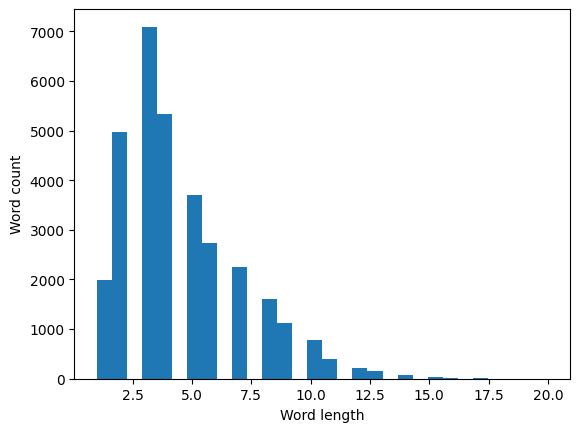

In [8]:
# initialize word lengths
wordlengths = np.zeros(len(words))

# loop over words and get length
for wordi in range(len(words)):
  wordlengths[wordi] = len(words[wordi])

# show in a plot
plt.hist(wordlengths,bins=30)
plt.xlabel('Word length')
plt.ylabel('Word count')
plt.show()

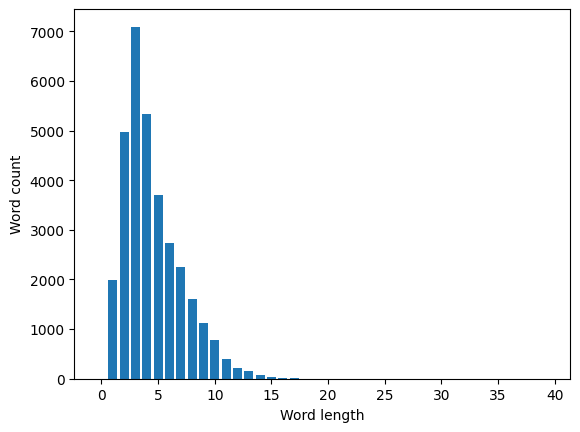

In [9]:
# alternative method

wordcounts = np.zeros(40)
for wrd in words:
  wordcounts[len(wrd)] += 1


plt.bar(range(len(wordcounts)),wordcounts)
plt.xlabel('Word length')
plt.ylabel('Word count')
plt.show()

# Letter frequencies

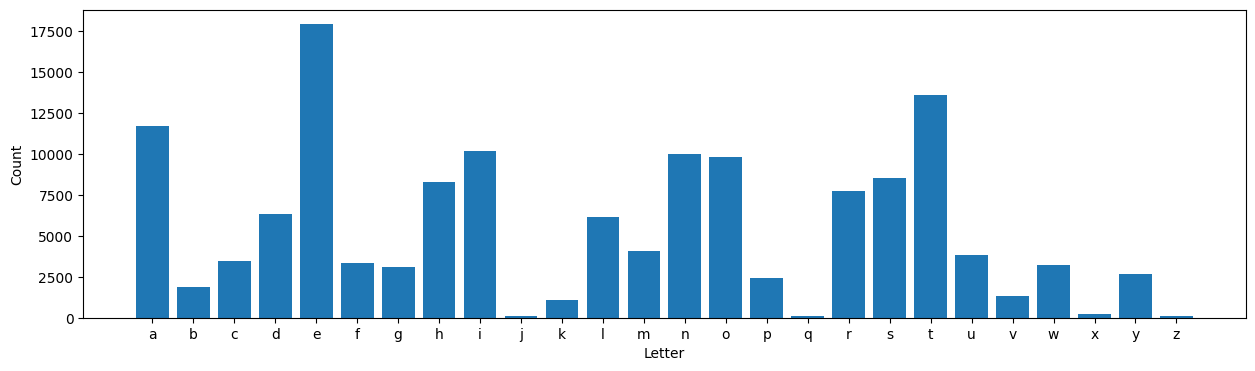

In [10]:
# now repeat for letter frequencies

letters = string.ascii_lowercase
numLetters = len(letters)
lettercounts = np.zeros(numLetters)

n = 0
for i in letters:
  lettercounts[n] = text.lower().count(i)
  n += 1


fig,ax = plt.subplots(1,figsize=(15,4))
ax.bar(range(numLetters),lettercounts)
ax.set_xticks(range(numLetters))
ax.set_xticklabels(letters)
ax.set_xlabel('Letter')
ax.set_ylabel('Count')
plt.show()

# Letter entropy

0.9999999999999999


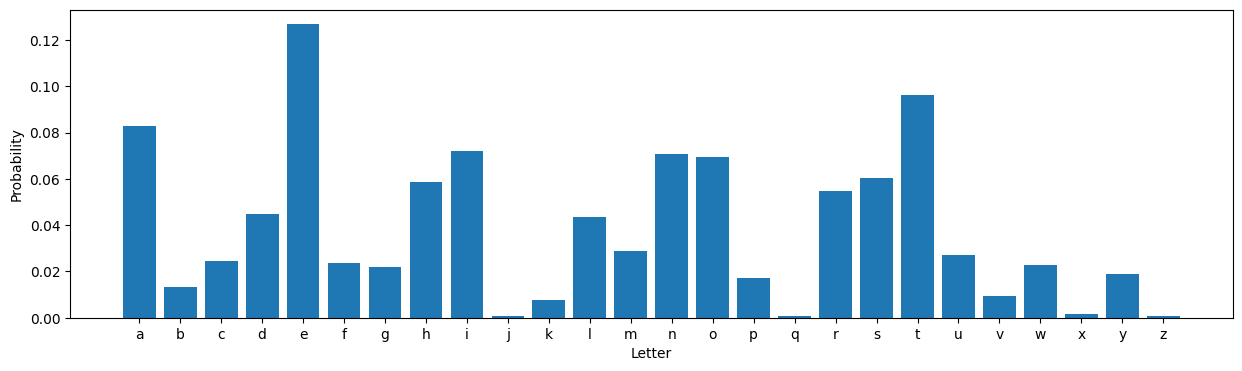

In [11]:
# compute entropy of letters

# convert frequency to probability
letterprob = lettercounts / sum(lettercounts)

# must sum to 1
print(sum(letterprob))

# show it
fig,ax = plt.subplots(1,figsize=(15,4))
ax.bar(range(numLetters),letterprob)
ax.set_xticks(range(numLetters))
ax.set_xticklabels(letters)
ax.set_xlabel('Letter')
ax.set_ylabel('Probability')
fig;


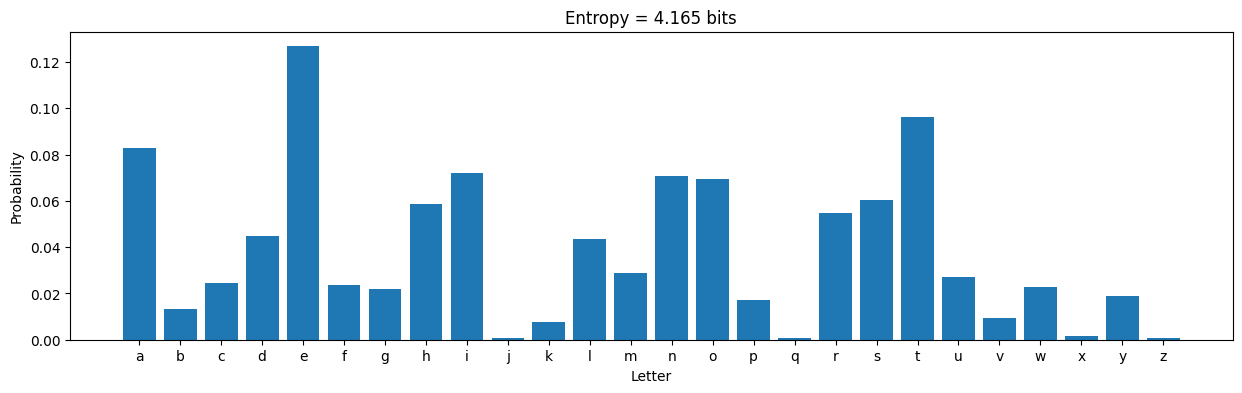

In [12]:
# compute overall entropy and re-plot

entropy = -sum( letterprob * np.log2(letterprob+np.finfo(float).eps) )

ax.set_title('Entropy = %.3f bits'%entropy)
fig

In [14]:
# now check out
# https://cs.stanford.edu/people/eroberts/courses/soco/projects/1999-00/information-theory/entropy_of_english_9.html

# Conditional (sequence) entropy

In [15]:
# now for conditional entropy

# initialize matrix
probmat = np.zeros((numLetters,numLetters))

# loop through letters
for i in range(len(text)-1):

  # get the current characters
  currlet = text[i].lower()
  nextlet = text[i+1].lower()

  # consider only if this and following characters are actually letters
  if currlet in letters and nextlet in letters:
    probmat[letters.index(currlet),letters.index(nextlet)] += 1


### NOTE about the code in this cell:
# In the video, I neglected to add .lower() to the text,
# which means my code excluded upper-case letters. (See also Q&A for this video.)

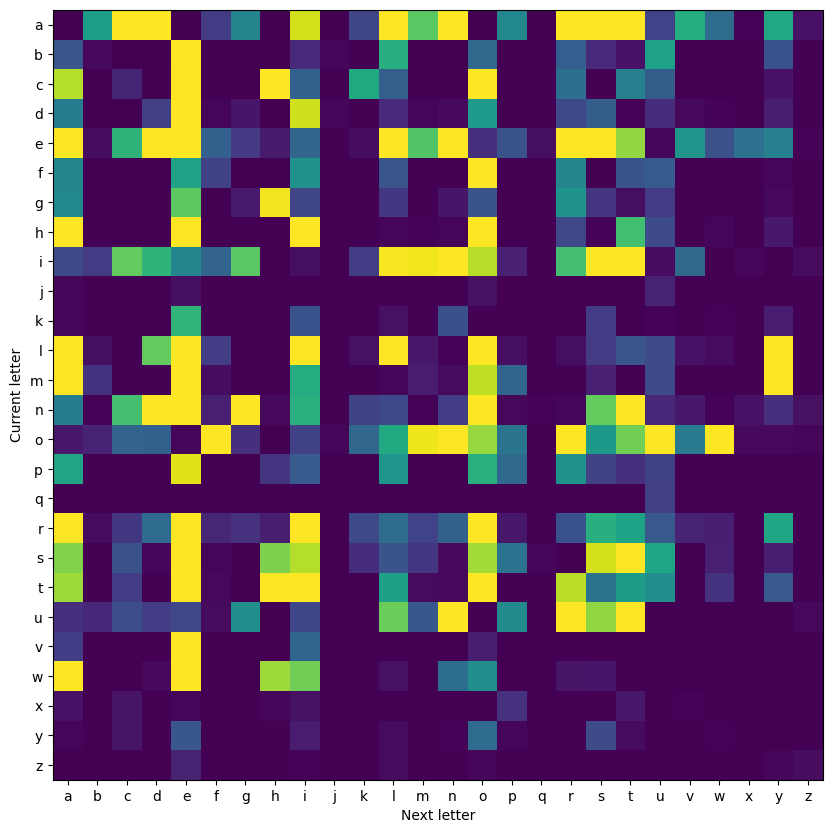

In [16]:
# show the matrix!

fig,ax = plt.subplots(1,figsize=(10,10))

ax.imshow(probmat,vmax=500)
ax.set_ylabel('Current letter')
ax.set_xlabel('Next letter')
ax.set_xticks(range(numLetters))
ax.set_yticks(range(numLetters))
ax.set_xticklabels(letters)
ax.set_yticklabels(letters)
plt.show()

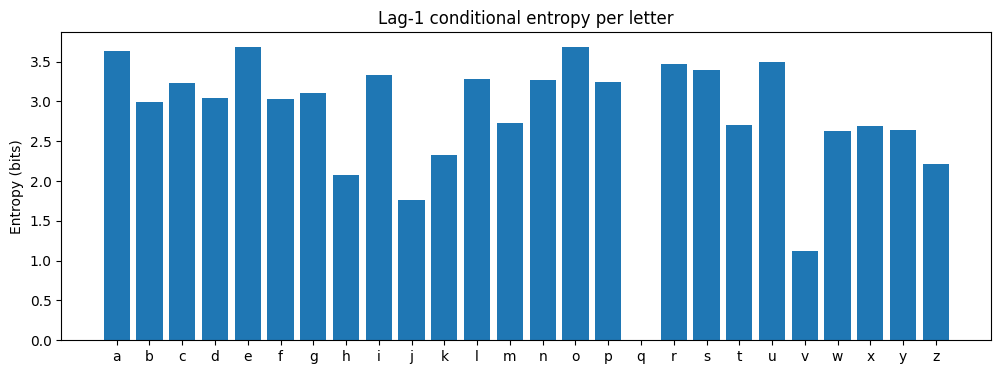

In [17]:
# now compute conditional entropy

condentr = np.zeros(numLetters)

for i in range(numLetters):
  probs = probmat[i,:]
  probs = probs / sum(probs)
  condentr[i] = -sum(probs*np.log2(probs+np.finfo(float).eps))


fig,ax = plt.subplots(1,figsize=(12,4))
ax.bar(range(numLetters),condentr)
ax.set_xticks(range(numLetters))
ax.set_xticklabels(letters)
ax.set_ylabel('Entropy (bits)')
ax.set_title('Lag-1 conditional entropy per letter')
plt.show()

# Bonus: Make a word cloud

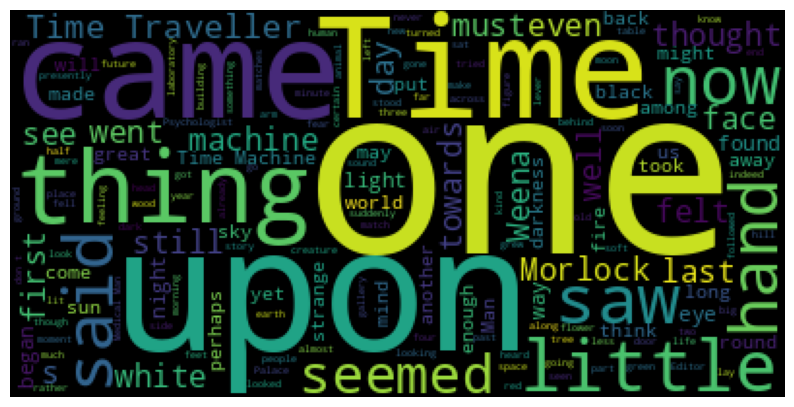

In [18]:
# bonus: word cloud
from wordcloud import WordCloud

wordcloud = WordCloud().generate(text)

plt.figure(figsize=(10,10))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()